#  **DIGITAL MARKETING CAMPAIN ANALYSIS**






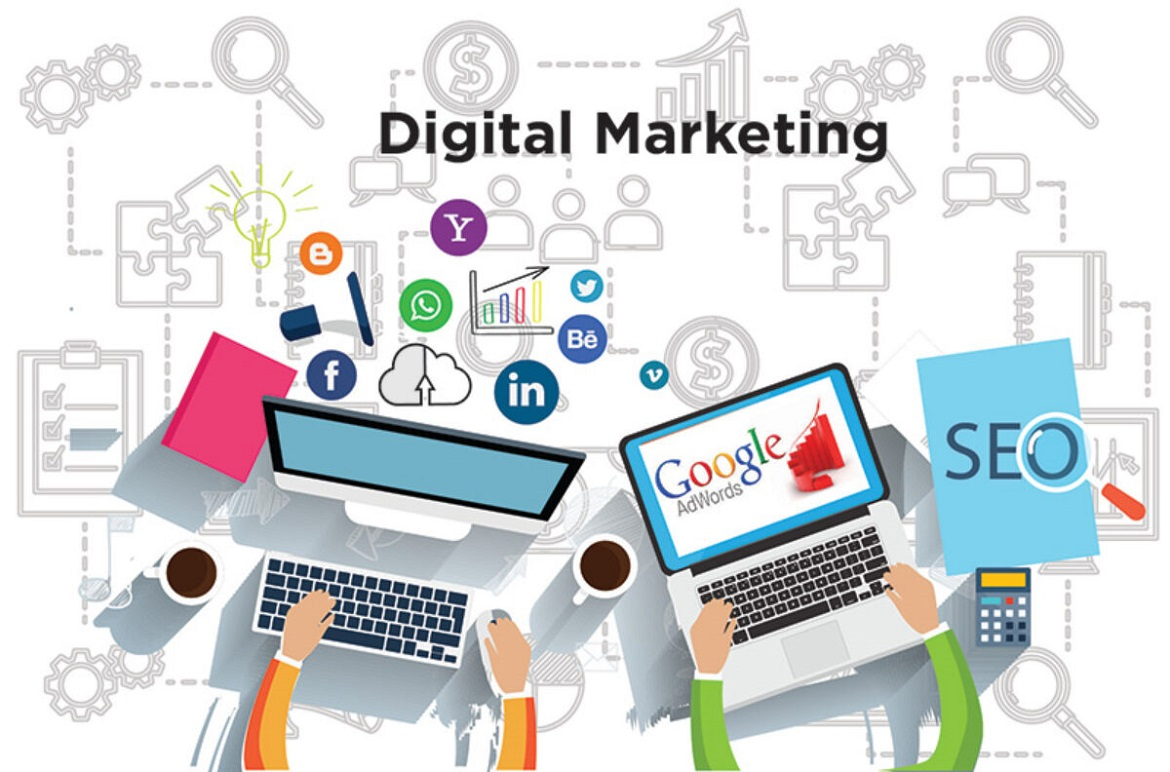

### **PROJECT CONTEXT**

In digital marketing, customers do not generate equal value.
Some campaigns lead to profitable conversions, while others result in unnecessary advertising costs.

Therefore, evaluating performance based only on traditional metrics such as conversion rate or cost per acquisition is not sufficient for making optimal business decisions.

### **OBJRCTIVE**

This project aims to develop a data-driven framework to optimize advertising decisions by:

Estimating the probability of customer conversion
Translating model outputs into real-world financial impact
Maximizing expected return from marketing activities
 Methodology

Instead of focusing solely on predictive accuracy, this project emphasizes business value through the following steps:

Building a classification model to predict conversion probability
Calibrating predicted probabilities to better reflect real-world outcomes
Estimating Customer Lifetime Value (LTV) for each customer
Computing Expected Value (EV) as a unified decision metric
### **DECISION FRAMEWORK**

All marketing decisions are based on Expected Value:

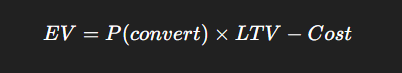



If EV > 0 → the customer is considered profitable and should be targeted

If EV < 0 → the customer is not profitable and should be excluded
### **EXPECTED OUTCOME**

This framework enables more efficient allocation of marketing budget by prioritizing high-value customers and eliminating unprofitable segments, ultimately improving overall campaign profitability.

---

### Import Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV


Load Dataset

Link Dataset:
https://www.kaggle.com/code/devraai/digital-marketing-campaign-analysis-and-prediction/notebook

In [ ]:
file_path = '/content/marketing_campaign_ad.csv'
df = pd.read_csv(file_path)
display(df.head())

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


**Information Data**

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         8000 non-null   int64  
 1   Age                8000 non-null   int64  
 2   Gender             8000 non-null   object 
 3   Income             8000 non-null   int64  
 4   CampaignChannel    8000 non-null   object 
 5   CampaignType       8000 non-null   object 
 6   AdSpend            8000 non-null   float64
 7   ClickThroughRate   8000 non-null   float64
 8   ConversionRate     8000 non-null   float64
 9   WebsiteVisits      8000 non-null   int64  
 10  PagesPerVisit      8000 non-null   float64
 11  TimeOnSite         8000 non-null   float64
 12  SocialShares       8000 non-null   int64  
 13  EmailOpens         8000 non-null   int64  
 14  EmailClicks        8000 non-null   int64  
 15  PreviousPurchases  8000 non-null   int64  
 16  LoyaltyPoints      8000 

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


## **DATA TYPE**

In [ ]:
df = df.drop(columns=['CustomerID'])
df['Conversion'] = df['Conversion'].astype('category')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                8000 non-null   int64   
 1   Gender             8000 non-null   object  
 2   Income             8000 non-null   int64   
 3   CampaignChannel    8000 non-null   object  
 4   CampaignType       8000 non-null   object  
 5   AdSpend            8000 non-null   float64 
 6   ClickThroughRate   8000 non-null   float64 
 7   ConversionRate     8000 non-null   float64 
 8   WebsiteVisits      8000 non-null   int64   
 9   PagesPerVisit      8000 non-null   float64 
 10  TimeOnSite         8000 non-null   float64 
 11  SocialShares       8000 non-null   int64   
 12  EmailOpens         8000 non-null   int64   
 13  EmailClicks        8000 non-null   int64   
 14  PreviousPurchases  8000 non-null   int64   
 15  LoyaltyPoints      8000 non-null   int64   
 16  Conver

**Unique Data**

In [ ]:
cat_cols = ['CampaignChannel', 'CampaignType', 'Gender']

for col in cat_cols:
    print(f"\n Column: {col}")
    print("-" * 30)


    print("Unique values:")
    print(df[col].unique())

    print("\nValue counts:")
    print(df[col].value_counts(dropna=False))


    print("\nValues with leading/trailing spaces:")
    print(df[df[col].str.strip() != df[col]][col])


 Column: CampaignChannel
------------------------------
Unique values:
['Social Media' 'Email' 'PPC' 'Referral' 'SEO']

Value counts:
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: CampaignChannel, dtype: object)

 Column: CampaignType
------------------------------
Unique values:
['Awareness' 'Retention' 'Conversion' 'Consideration']

Value counts:
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: CampaignType, dtype: object)

 Column: Gender
------------------------------
Unique values:
['Female' 'Male']

Value counts:
Gender
Female    4839
Male      3161
Name: count, dtype: int64

Values with leading/trailing spaces:
Series([], Name: Gender, dtype: object)


## **HANDLE MISSING VALUES**

In [ ]:
df.isnull().sum()
df = df.dropna()

## **REMOVE DUPLICATES**

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates()

## **OUTLIERS**

In [ ]:
num_cols = [
    'Income',
    'AdSpend',
    'WebsiteVisits',
    'TimeOnSite',
    'PagesPerVisit',
    'PreviousPurchases',
    'LoyaltyPoints'
]

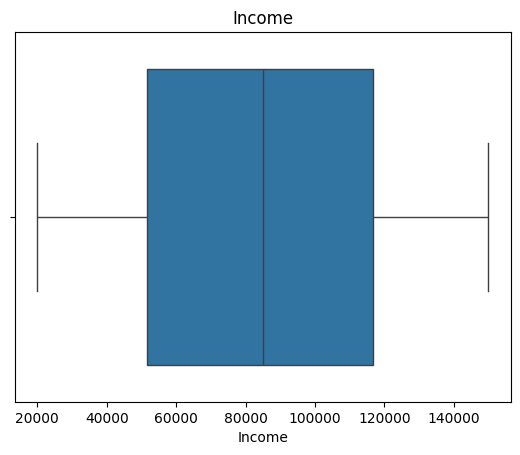

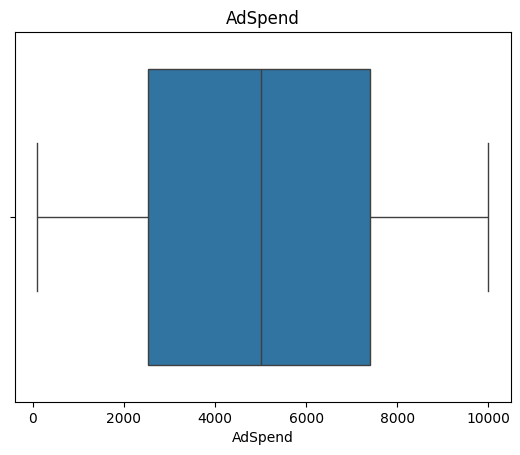

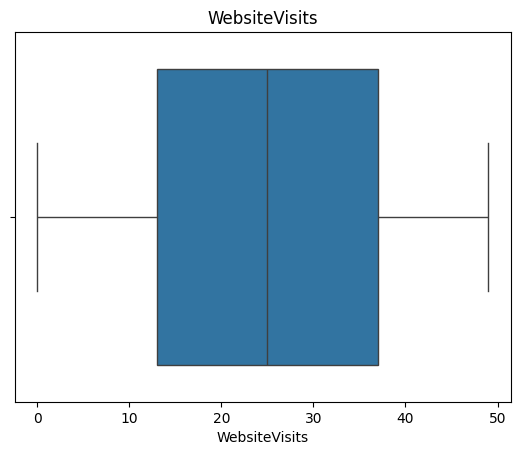

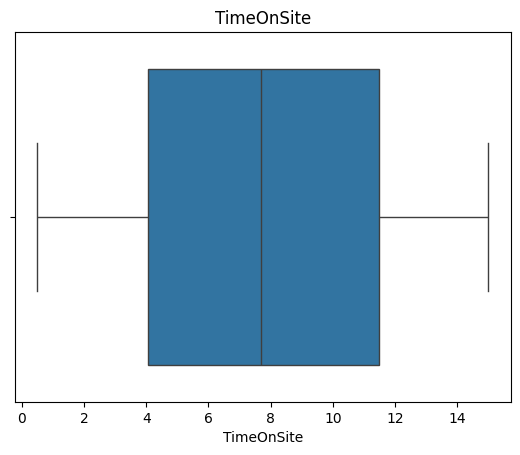

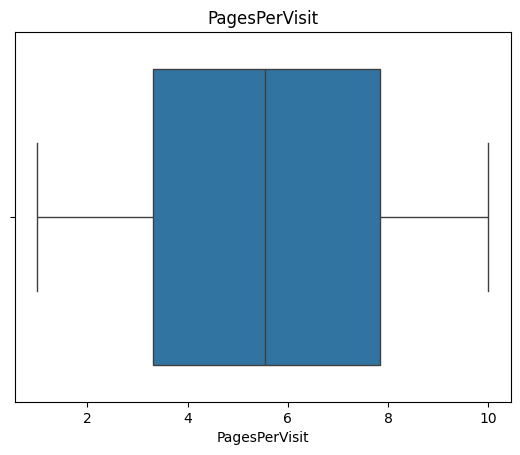

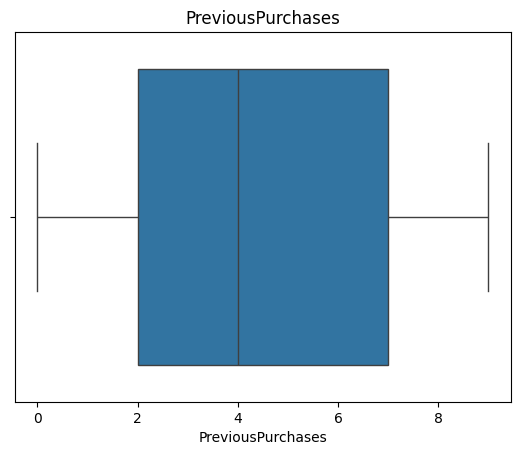

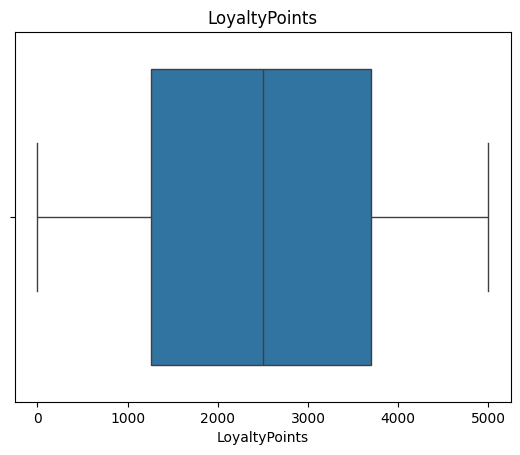

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

The selected numerical features (Income, AdSpend, WebsiteVisits, TimeOnSite, PagesPerVisit, PreviousPurchases, and LoyaltyPoints) do not exhibit significant outliers, indicating a relatively stable distribution without extreme values that could distort model training

In [ ]:
def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] < lower) | (df[col] > upper)]
    find_outliers('Income')

## EDA (Exploratory Data Analysis)

**Conversion**

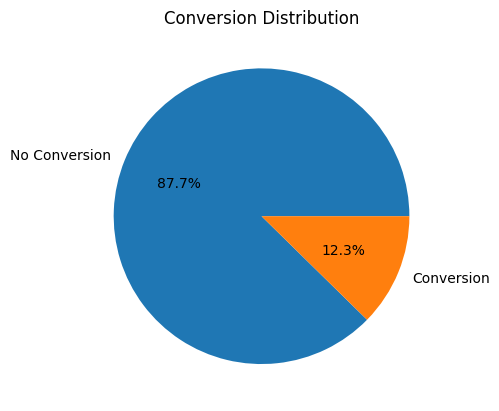

In [ ]:
conversion_counts = df['Conversion'].value_counts()
labels = ['No Conversion', 'Conversion']
plt.figure()
plt.pie(
    conversion_counts,
    labels=labels,
    autopct='%1.1f%%'
)
plt.title('Conversion Distribution')
plt.show()

**Gender**

/tmp/ipykernel_3059/4073436745.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Conversion', data=df, ax=ax2, palette='pastel')


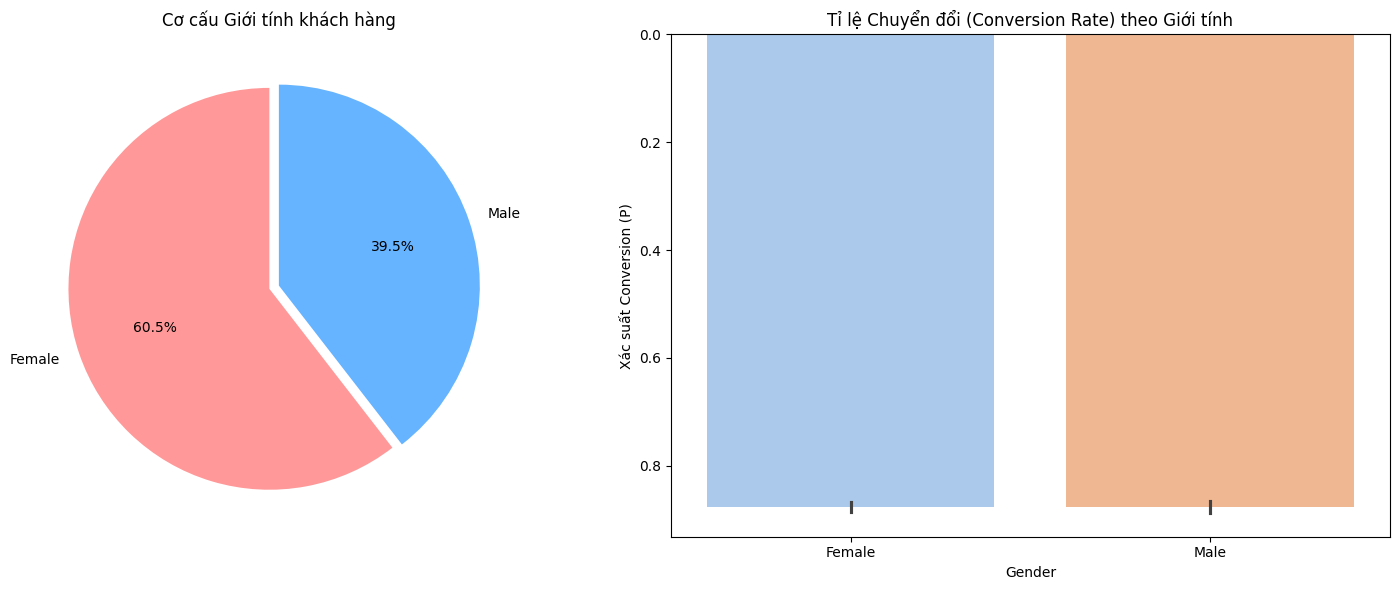

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
gender_counts = df['Gender'].value_counts()
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.05, 0))
ax1.set_title('Cơ cấu Giới tính khách hàng')
sns.barplot(x='Gender', y='Conversion', data=df, ax=ax2, palette='pastel')
ax2.set_title('Tỉ lệ Chuyển đổi (Conversion Rate) theo Giới tính')
ax2.set_ylabel('Xác suất Conversion (P)')
plt.tight_layout()
plt.show()

**Age**

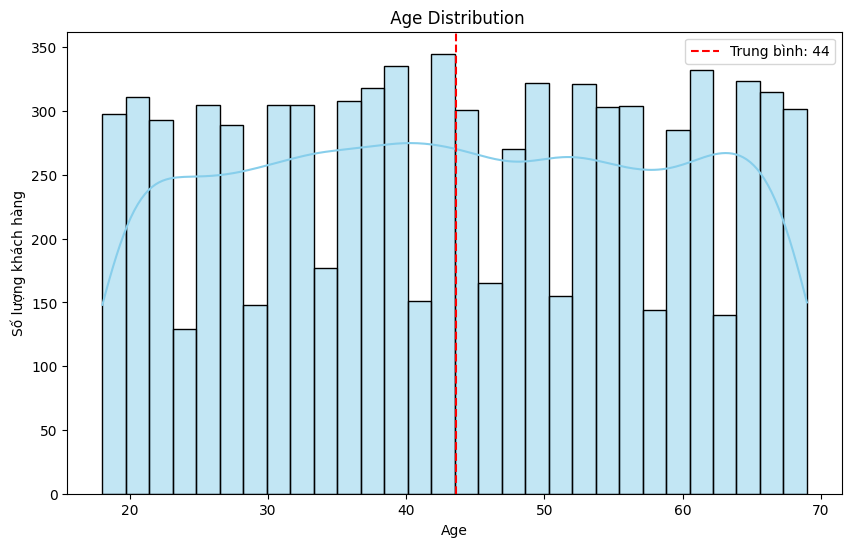

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=30)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Age'].mean():.0f}")
plt.title(' Age Distribution')
plt.xlabel('Age')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.show()



**Income**



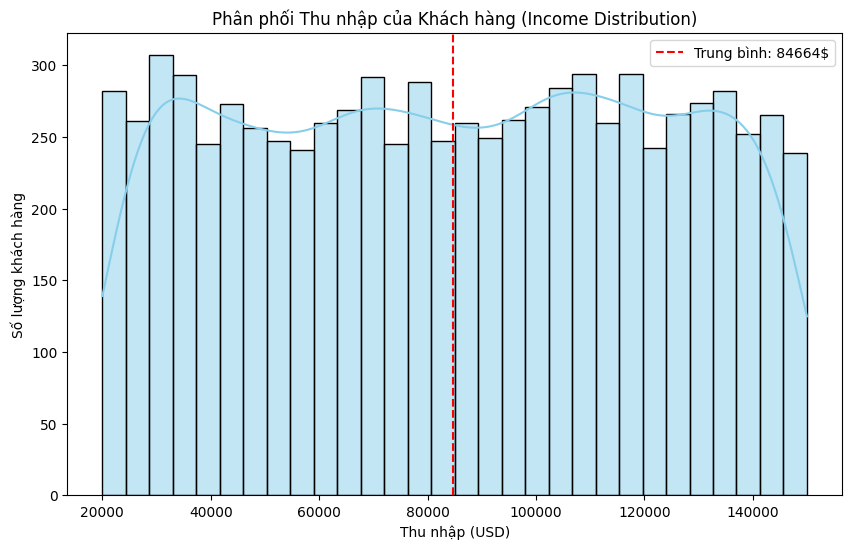

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Income'], kde=True, color='skyblue', bins=30)
plt.axvline(df['Income'].mean(), color='red', linestyle='--', label=f"Trung bình: {df['Income'].mean():.0f}$")
plt.title('Phân phối Thu nhập của Khách hàng (Income Distribution)')
plt.xlabel('Thu nhập (USD)')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.show()

**CampaignChannel and AdSpend**

/tmp/ipykernel_3059/3259452564.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CampaignChannel', y='AdSpend', data=mean_spend_data, palette='Greens_r')


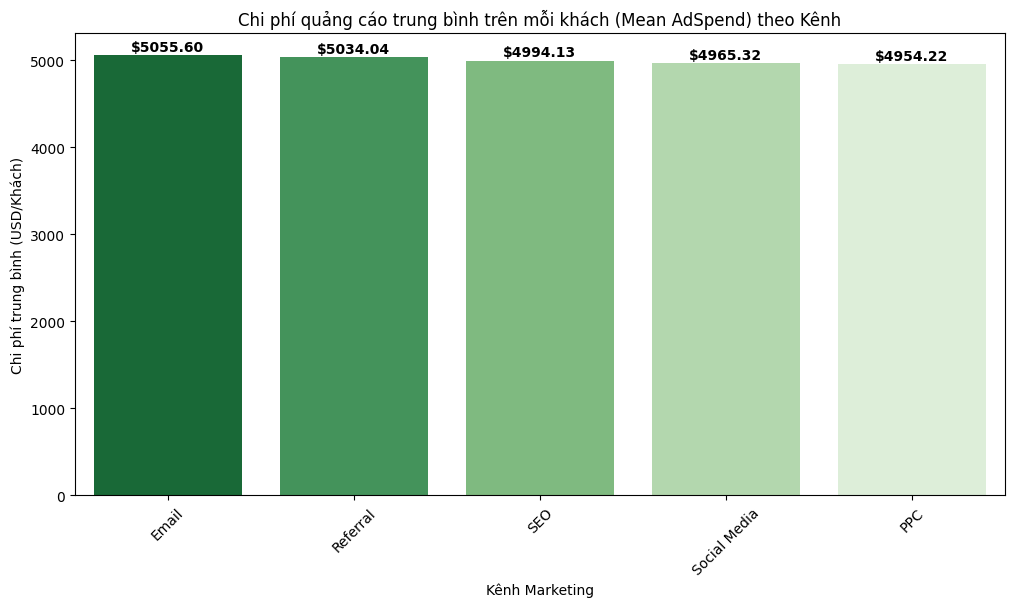

In [ ]:
plt.figure(figsize=(12, 6))
mean_spend_data = df.groupby('CampaignChannel')['AdSpend'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='CampaignChannel', y='AdSpend', data=mean_spend_data, palette='Greens_r')
for i, v in enumerate(mean_spend_data['AdSpend']):
    plt.text(i, v + (v*0.01), f'${v:.2f}', ha='center', fontweight='bold')
plt.title('Chi phí quảng cáo trung bình trên mỗi khách (Mean AdSpend) theo Kênh')
plt.ylabel('Chi phí trung bình (USD/Khách)')
plt.xlabel('Kênh Marketing')
plt.xticks(rotation=45)
plt.show()

**CampaignChannel and Conversion**

/tmp/ipykernel_3059/702660752.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CampaignChannel', y='Conversion', data=eff_plot_data, palette='Greens_r')


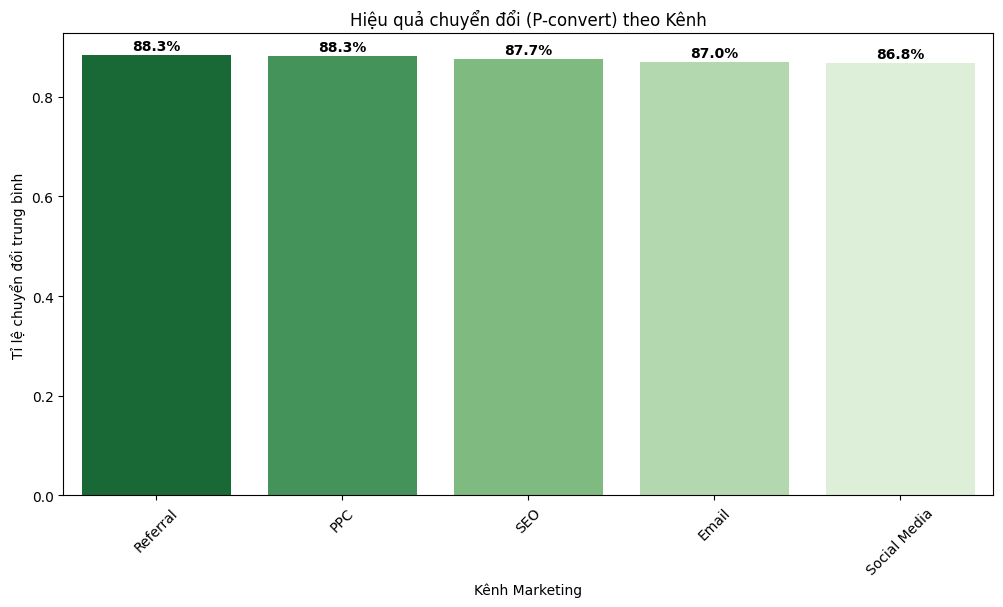

In [ ]:
plt.figure(figsize=(12, 6))
eff_data = df.copy()
eff_data['Conversion'] = eff_data['Conversion'].astype(float)
eff_plot_data = eff_data.groupby('CampaignChannel')['Conversion'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='CampaignChannel', y='Conversion', data=eff_plot_data, palette='Greens_r')
for i, v in enumerate(eff_plot_data['Conversion']):
    plt.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontweight='bold')

plt.title('Hiệu quả chuyển đổi (P-convert) theo Kênh')
plt.ylabel('Tỉ lệ chuyển đổi trung bình')
plt.xlabel('Kênh Marketing')
plt.xticks(rotation=45)
plt.show()

**CampaignType and Conversion**

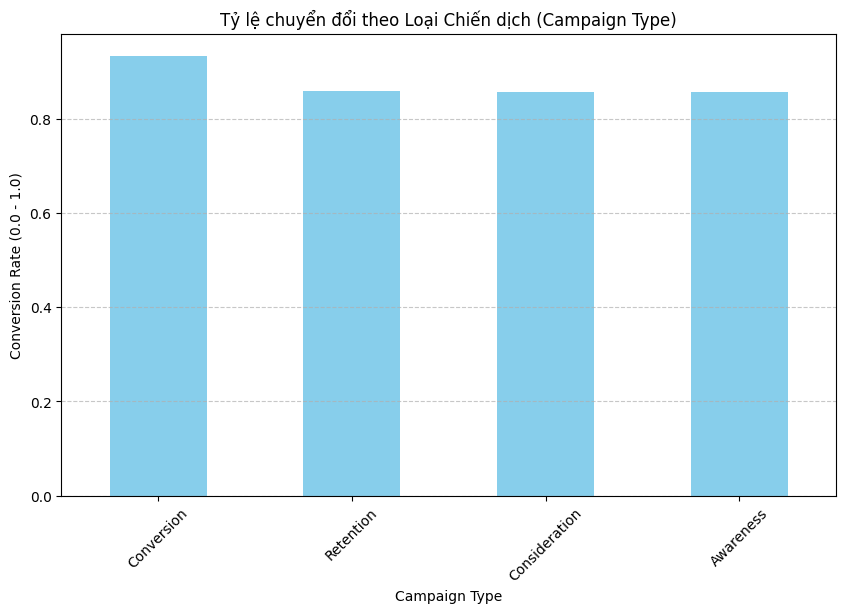

In [ ]:
type_conv = df.groupby('CampaignType')['Conversion'].apply(lambda x: x.astype(float).mean())
type_conv.sort_values(ascending=False).plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Tỷ lệ chuyển đổi theo Loại Chiến dịch (Campaign Type)')
plt.ylabel('Conversion Rate (0.0 - 1.0)')
plt.xlabel('Campaign Type')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Those Quantitative / Numerical and Conversion**

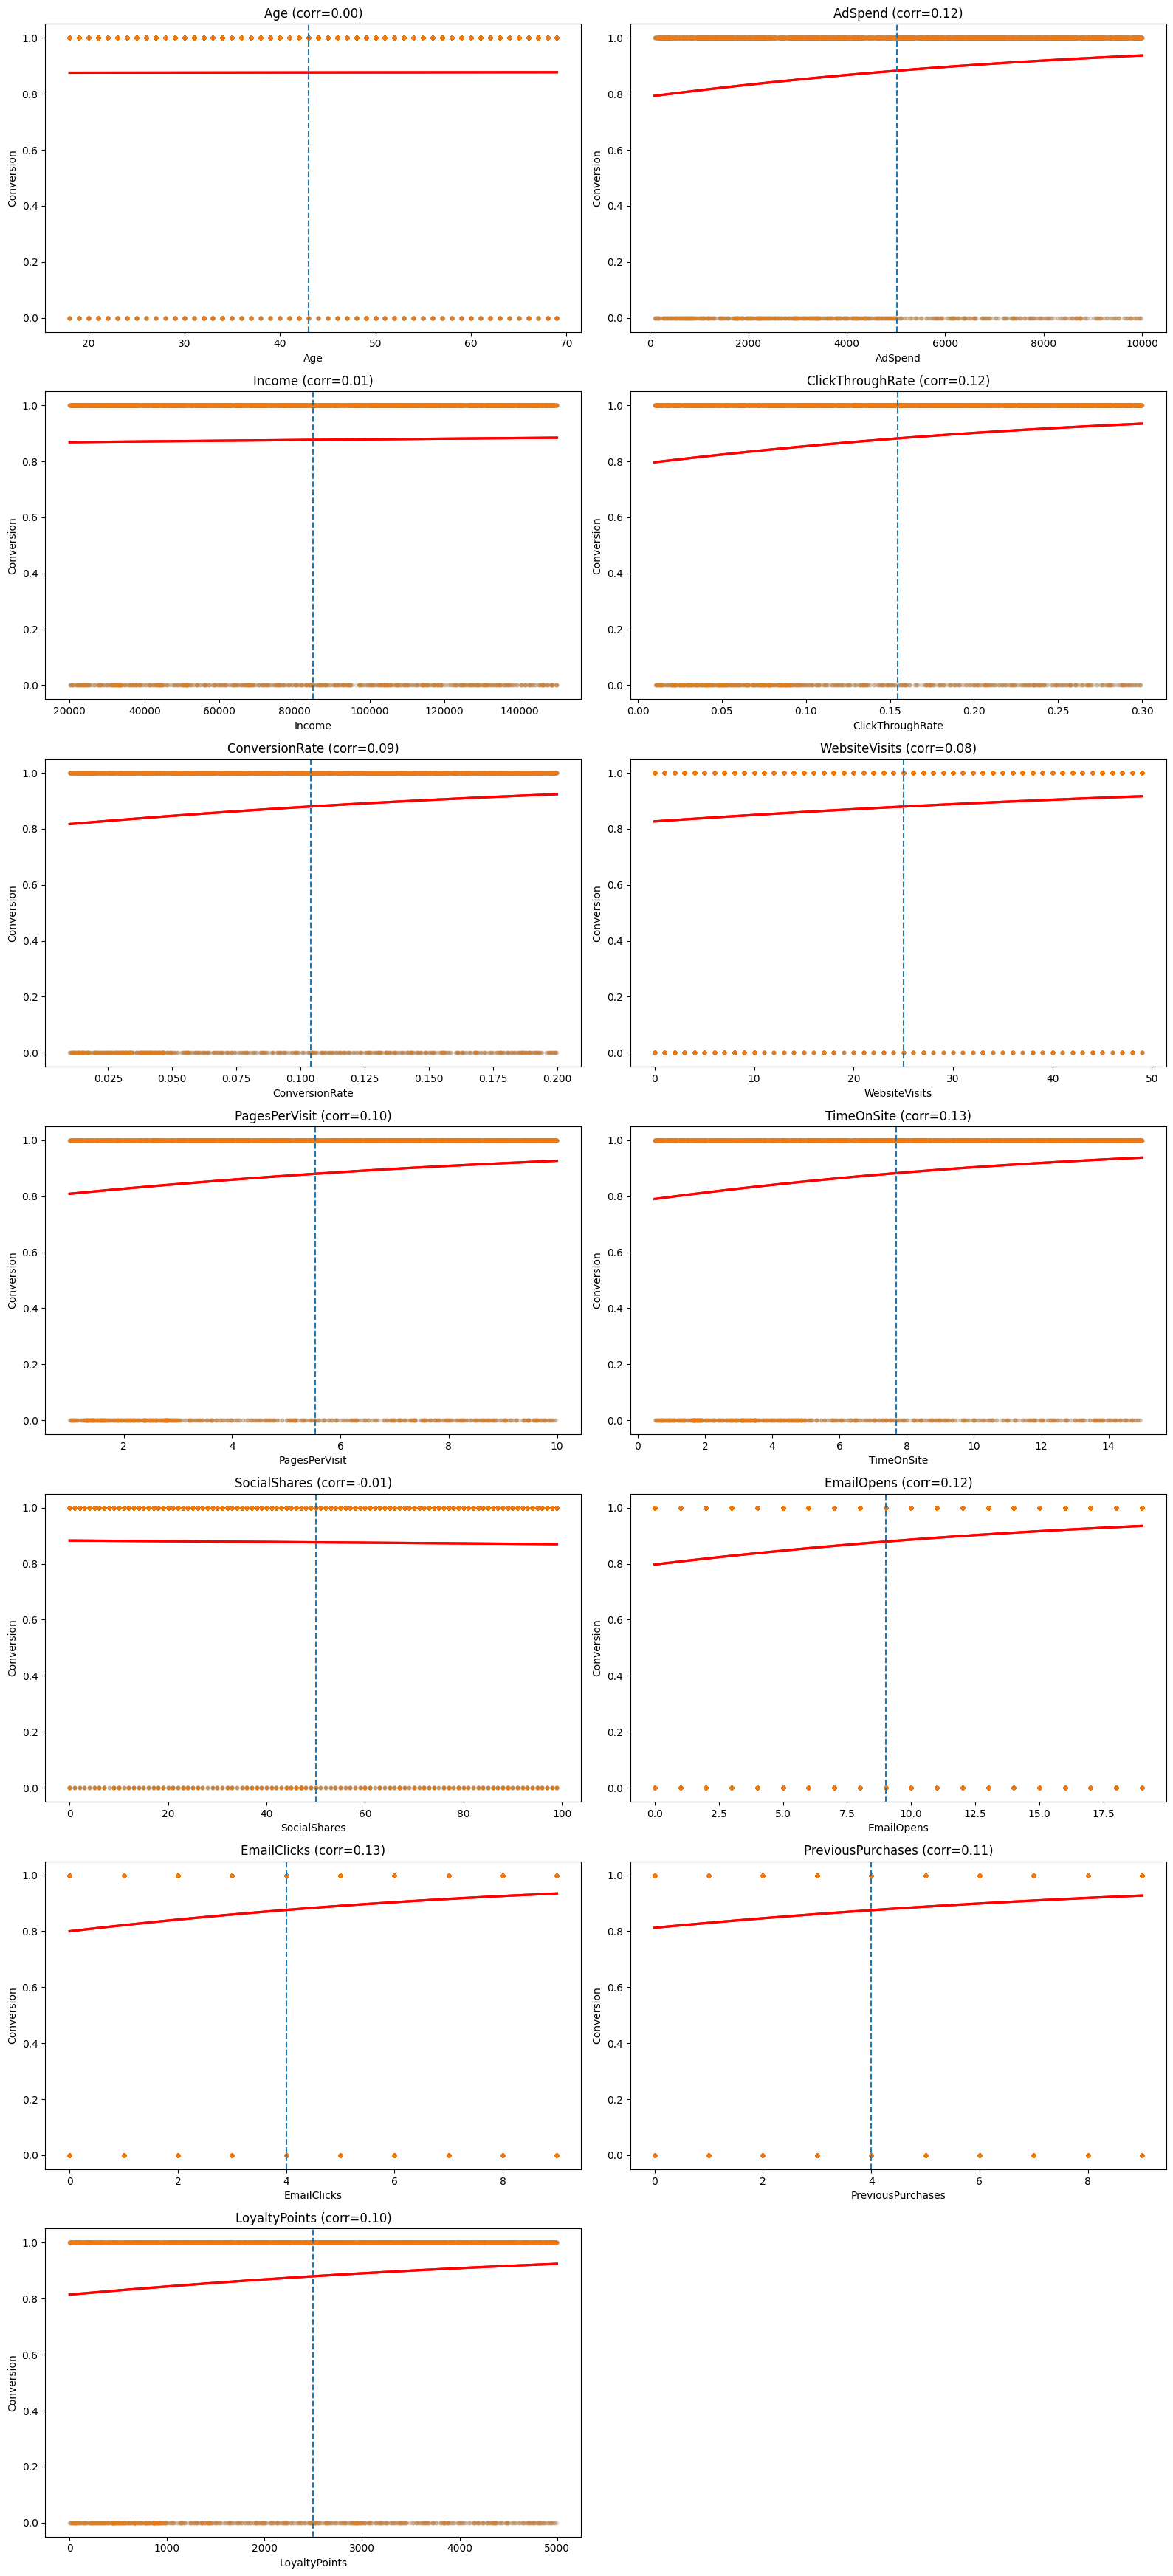

In [ ]:
numeric_cols = [
    'Age','AdSpend','Income','ClickThroughRate', 'ConversionRate', 'WebsiteVisits',
    'PagesPerVisit', 'TimeOnSite', 'SocialShares',
    'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints'
]
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()
df_plot = df.copy()
df_plot['Conversion'] = df_plot['Conversion'].astype(float)

for i, col in enumerate(numeric_cols):

    sns.regplot(x=col, y='Conversion', data=df_plot,
                logistic=True, ci=None,
                scatter_kws={'alpha':0.1, 's':10},
                line_kws={'color':'red'}, ax=axes[i])

    axes[i].set_title(f'Relationship: {col} vs Conversion')
    axes[i].set_ylim(-0.05, 1.05)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
for i, col in enumerate(numeric_cols):
    sns.regplot(
        x=col, y='Conversion', data=df_plot,
        logistic=True, ci=None,
        scatter_kws={'alpha':0.1, 's':10},
        line_kws={'color':'red'}, ax=axes[i]
    )

    corr_value = df_plot[col].corr(df_plot['Conversion'])
    median_val = df_plot[col].median()

    axes[i].axvline(median_val, linestyle='--')
    axes[i].set_title(f'{col} (corr={corr_value:.2f})')
plt.tight_layout()
plt.show()

Most numerical features show weak individual correlations with conversion (ranging from ~0.08 to 0.13), indicating that no single variable strongly drives customer conversion.

Behavioral features such as engagement (time on site, pages per visit), interaction (click-through rate, email clicks), and purchase history (previous purchases, loyalty points) exhibit a positive but modest relationship with conversion.

In contrast, demographic variables like age and income show little to no impact. Additionally, social shares do not appear to translate into actual purchasing behavior.

Overall, conversion is driven by a combination of multiple factors rather than any single dominant feature.

Customer conversion is influenced by cumulative engagement signals rather than any single dominant feature

In [ ]:
for i, col in enumerate(numeric_cols):
    sns.regplot(
        x=col, y='Conversion', data=df_plot,
        logistic=True, ci=None,
        scatter_kws={'alpha':0.1, 's':10},
        line_kws={'color':'red'}, ax=axes[i]
    )

    corr_value = df_plot[col].corr(df_plot['Conversion'])
    median_val = df_plot[col].median()

    axes[i].axvline(median_val, linestyle='--')
    axes[i].set_title(f'{col} (corr={corr_value:.2f})')

### Dummies Category

In [ ]:
df_model = pd.get_dummies(df, drop_first=True)

In [ ]:
df_model.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,LoyaltyPoints,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention,Conversion_1
0,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,...,688,False,False,False,False,True,False,False,False,True
1,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,...,3459,True,False,False,False,False,False,False,True,True
2,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,...,2337,False,True,False,False,False,False,False,False,True
3,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,...,2463,False,True,False,False,False,False,True,False,True
4,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,...,4345,False,True,False,False,False,False,True,False,True


## **MACHINE LEARNING**





### Build model

In [ ]:
X = df_model.drop(columns=['Conversion_1'])
y = df_model['Conversion_1']

### Split Data 80:20

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

### AUC

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob)

np.float64(0.7305216230880909)

In [ ]:
comparison = pd.DataFrame({
    'Thực tế (Y)': y_test,
    'Xác suất dự báo (P-convert)': y_prob
})
print(comparison.head(20))

      Thực tế (Y)  Xác suất dự báo (P-convert)
2215        False                     0.881603
2582         True                     0.838666
1662         True                     0.691019
3027         True                     0.957233
4343         True                     0.748977
2680        False                     0.886138
1765         True                     0.912915
1123         True                     0.884292
4054        False                     0.852090
3761         True                     0.953734
1535         True                     0.958475
2944         True                     0.887421
2987        False                     0.688367
4291         True                     0.923214
4342         True                     0.887310
4424        False                     0.786210
7941         True                     0.923604
4997         True                     0.972907
2748         True                     0.852457
2302         True                     0.937441


## **Calibration**

In [ ]:
calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv=10)
calibrated_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

CalibratedClassifierCV(cv=10, estimator=LogisticRegression(max_iter=1000))

In [ ]:
y_prob_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Before:", y_prob[:5])
print("After :", y_prob_calibrated[:5])

Before: [0.88160297 0.83866619 0.69101872 0.95723304 0.74897726]
After : [0.88308252 0.83279742 0.63432273 0.9609962  0.69286112]


###  **Plot Calibration Curve**

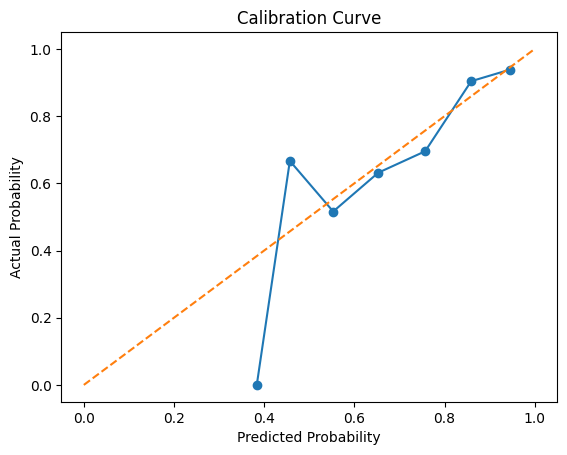

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_calibrated, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.title('Calibration Curve')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')

plt.show()

The calibration curve indicates that predicted probabilities are generally aligned with observed outcomes, particularly in higher probability ranges. Minor deviations exist in lower probability segments, suggesting slight overestimation.

### **INSIGHT**

**Customer LifeTime Value**





Customer Lifetime Value (LTV) represents the total expected revenue generated from a customer over time

In [ ]:
df['LTV'] = (
    df['Income'] * 0.05 +
    df['PreviousPurchases'] * 50 +
    df['LoyaltyPoints'] * 0.1
)

In this project, LTV is simulated using available features due to the absence of real revenue data. The formula combines:

Income as a proxy for purchasing power
PreviousPurchases to reflect historical buying behavior
LoyaltyPoints to capture customer engagement and retention
These weights are heuristically chosen to approximate customer value and enable downstream expected value calculations.

In real-world scenarios, LTV should be calculated using actual revenue data, such as:

Transaction history
Order value
Purchase frequency
Customer retention rate

The current approach is a simplified proxy for demonstration purposes only.

In [ ]:
df_test = X_test.copy()
df_test['P_convert'] = y_prob_calibrated
df_test['Actual'] = y_test

In [ ]:
df_test.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention,P_convert,Actual
2215,42,84067,4763.087209,0.264393,0.020226,35,2.328249,11.836823,25,12,...,False,False,False,False,True,False,False,True,0.883083,False
2582,50,124448,5820.990747,0.178070,0.164451,28,9.859430,8.436763,46,6,...,False,False,False,False,True,True,False,False,0.832797,True
1662,43,89285,3293.605817,0.226931,0.025642,27,3.248306,6.376954,96,11,...,False,False,True,False,False,False,False,False,0.634323,True
3027,46,125775,2265.832629,0.010172,0.074557,41,7.889309,6.480653,52,11,...,True,False,True,False,False,False,True,False,0.960996,True
4343,34,117332,2102.996295,0.275239,0.138175,13,5.839536,1.095898,66,13,...,False,True,False,False,False,False,True,False,0.692861,True


In [ ]:
df_test['AdSpend'] = df.loc[X_test.index, 'AdSpend']
df_test['LTV'] = df.loc[X_test.index, 'LTV']

In [ ]:
df_test.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention,P_convert,Actual,LTV
2215,42,84067,4763.087209,0.264393,0.020226,35,2.328249,11.836823,25,12,...,False,False,False,True,False,False,True,0.883083,False,4289.85
2582,50,124448,5820.990747,0.178070,0.164451,28,9.859430,8.436763,46,6,...,False,False,False,True,True,False,False,0.832797,True,6586.00
1662,43,89285,3293.605817,0.226931,0.025642,27,3.248306,6.376954,96,11,...,False,True,False,False,False,False,False,0.634323,True,4606.15
3027,46,125775,2265.832629,0.010172,0.074557,41,7.889309,6.480653,52,11,...,False,True,False,False,False,True,False,0.960996,True,6952.15
4343,34,117332,2102.996295,0.275239,0.138175,13,5.839536,1.095898,66,13,...,True,False,False,False,False,True,False,0.692861,True,6123.30


In [ ]:
df_test['EV'] = df_test['P_convert'] * df_test['LTV'] - df_test['AdSpend']

In [ ]:
df_test['Decision'] = df_test['EV'].apply(lambda x: 'KEEP' if x > 0 else 'CUT')

In [ ]:
df_test['Decision'].value_counts()

,count
Decision,
CUT,971
KEEP,629


In [ ]:
df_test.groupby('Decision')['EV'].mean()

,EV
Decision,
CUT,-3032.849835
KEEP,2314.621512


In [ ]:
df_test.groupby('Decision')['AdSpend'].sum()

,AdSpend
Decision,
CUT,6.499562e+06
KEEP,1.539558e+06


In [ ]:
df_test.head()

,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,...,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention,P_convert,Actual,LTV,EV,Decision
2215,42,84067,4763.087209,0.264393,0.020226,35,2.328249,11.836823,25,12,...,False,True,False,False,True,0.883083,False,4289.85,-974.795663,CUT
2582,50,124448,5820.990747,0.178070,0.164451,28,9.859430,8.436763,46,6,...,False,True,True,False,False,0.832797,True,6586.00,-336.186945,CUT
1662,43,89285,3293.605817,0.226931,0.025642,27,3.248306,6.376954,96,11,...,False,False,False,False,False,0.634323,True,4606.15,-371.820164,CUT
3027,46,125775,2265.832629,0.010172,0.074557,41,7.889309,6.480653,52,11,...,False,False,False,True,False,0.960996,True,6952.15,4415.157121,KEEP
4343,34,117332,2102.996295,0.275239,0.138175,13,5.839536,1.095898,66,13,...,False,False,False,True,False,0.692861,True,6123.30,2139.600220,KEEP


## **SUMMARY**

In this project, a classification model was developed to identify customers based on their expected financial value, enabling data-driven decisions to retain or exclude customers using Expected Value (EV).

While the model effectively identifies unprofitable segments, a full exclusion strategy may introduce business risk. Therefore, instead of removing 100% of low-value customers, an 80/20 strategy is applied: 80% of low-EV customers are excluded, while 20% are randomly retained as a control group.

This approach allows continuous validation of the model’s performance and helps detect potential misclassifications. If discrepancies are observed, the model can be retrained and improved accordingly.

This strategy balances cost optimization with risk mitigation, ensuring more reliable and robust marketing decisions.

=> We don’t blindly trust the model — we validate it through controlled experimentation.